In [1]:
import numpy as np
import matplotlib.pyplot as plt

### True Action Values

For each bandit, the action values $ q(a) $, where $ a = 1, \dots, 10 $, are selected from a normal (Gaussian) distribution:

$
q(a) \sim \mathcal{N}(0,1)
$

where the mean is **0** and the variance is **1**.

### Reward Calculation in Multi-Armed Bandit

On the $ t^{th} $ time step, given a specific bandit, the actual reward $ R_t $ is calculated as:

$
R_t = q(A_t) + \mathcal{N}(0,1)
$

where:  
- $ A_t $ is the action selected at time step $ t $.  
- $ q(A_t) $ is the true value of the selected action.  
- $ \mathcal{N}(0,1) $ represents a normally distributed noise term with mean 0 and variance 1.

### Stationary vs. Non-Stationary Environments

In the context of reinforcement learning and multi-armed bandit problems, an environment can be either stationary or non-stationary, \
depending on whether the true action values change over time.

#### Stationary Environment
- The true action values of all arms (or actions) remain constant over time.
- The best action at the beginning remains the best action throughout.
- Learning Strategy:
    - The sample-average method works well because past rewards are equally important.
    - No need for rapid adaptation, since the best action does not change.

#### Non-Stationary Environment
- The true action values change over time, meaning the optimal action may shift.
- The best action at one time step may no longer be the best later.
- Learning Strategy:
    - Exponential, recency-weighted average($ Q_{k+1} = Q_k + \alpha (R_k - Q_k) $ where $ α $ is fixed) are better.
    - More recent rewards should be given higher weight.

In [2]:
class MultiArmedBandit:
    """ 
    A class representing a Multi-Armed Bandit problem.

    Attributes:
        n_arms (int): Number of arms (actions).
        stationary (bool): Indicates whether the bandit is stationary or non-stationary.
        true_action_values (np.array): The true reward values for each arm (action).
        optimal_action (int): The index of the optimal action (highest expected reward).
    """
    
    def __init__(self, n_arms, stationary=True, mean=0, variance=1):
        """
        Initializes a multi-armed bandit environment.

        Args:
            n_arms (int): The number of available arms.
            stationary (bool): Whether the bandit's true action values are stationary. 
            mean (float): Mean of the true action value distribution.
            variance (float): Variance of the true action value distribution.
        """
        self.n_arms = n_arms
        self.stationary = stationary
        self.true_action_values = np.random.normal(mean, np.sqrt(variance), n_arms)
        self.optimal_action = np.argmax(self.true_action_values)

    def get_reward(self, action):
        """
        Returns a reward for selecting a given action.

        Args:
            action (int): The action (arm) chosen.

        Returns:
            float: The observed reward.
        """
        reward = self.true_action_values[action] + np.random.normal(0, 1)

        if not self.stationary:
            self.true_action_values += np.random.normal(0, 0.01, self.n_arms)
            self.optimal_action = np.argmax(self.true_action_values)

        return reward

### Greedy and ε-Greedy Action Selection

The simplest action selection rule chooses the action with the highest estimated value at time step $ t $:

$
A_t = \arg\max_{a} Q_t(a)
$

This greedy action selection exploits current knowledge to maximize immediate reward, but it does not explore potentially better actions.

#### ε-Greedy Method
To encourage exploration, the ε-greedy method selects the greedy action most of the time but, with probability $ \epsilon $, selects a random action:

$
A_t =
\begin{cases} 
\arg\max_{a} Q_t(a), & \text{with probability } 1 - \epsilon \\
\text{random action}, & \text{with probability } \epsilon
\end{cases}
$

This balances exploitation (choosing the best-known action) with exploration (discovering potentially better actions).


In [3]:
class EpsilonGreedySelector:
    """ 
    A class handling action selection using the epsilon-greedy strategy.

    Attributes:
        epsilon (float): Probability of choosing a random action (exploration).
    """

    def __init__(self, epsilon=0.1):
        """
        Initializes the EpsilonGreedySelector with a confidence parameter.

        Args:
            epsilon (float): Probability of choosing a random action (exploration).
        """
        self.epsilon = epsilon

    def select_action(self, n_arms, estimate_action_values):
        """ 
        Selects an action using the epsilon-greedy strategy.

        Args:
            n_arms (int): Number of arms (actions).
            estimate_action_values (np.array): Current estimates of action values.

        Returns:
            int: The selected action.
        """
        if np.random.rand() < self.epsilon:
            return np.random.choice(n_arms)
        return np.argmax(estimate_action_values)

### Upper Confidence Bound (UCB) Action Selection

The Upper Confidence Bound (UCB) action selection method balances exploration and exploitation by selecting actions based on both their estimated rewards and the uncertainty in those estimates.

#### Formula for UCB Action Selection
For each action $ a $, we compute the UCB value as:

$
Q(a) + c \sqrt{\frac{\ln t}{N(a) + 1}}
$

where:

- $ Q(a) $ is the estimated value of action $ a $.
- $ N(a) $ is the number of times action $ a $ has been selected.
- $ t $ is the current time step.
- $ c $ is a confidence parameter controlling the exploration-exploitation balance.

The UCB method selects the action that maximizes this value, ensuring that actions with higher uncertainty are explored more frequently.


In [4]:
class UCBSelector:
    """ 
    A class handling action selection using the Upper Confidence Bound (UCB) strategy.

    Attributes:
        c (float): Confidence level parameter controlling the trade-off between exploration 
                   and exploitation. A higher value increases exploration.
    """

    def __init__(self, c=2):
        """
        Initializes the UCBSelector with a confidence parameter.

        Args:
            c (float): Confidence parameter that balances exploration and exploitation.
        """
        self.c = c

    def select_action(self, n_arms, estimate_action_values, action_counts, time_step):
        """
        Selects an action using the Upper Confidence Bound (UCB) algorithm.

        Args:
            n_arms (int): Number of available actions (arms).
            estimate_action_values (list of float): Estimated values for each action.
            action_counts (list of int): Number of times each action has been selected.
            time_step (int): Current time step.

        Returns:
            int: The index of the selected action.
        """
        if time_step == 0:
            return np.random.choice(n_arms)

        # Compute UCB values
        ucb_values = estimate_action_values + self.c * np.sqrt(np.log(time_step + 1) / (action_counts + 1))

        return np.argmax(ucb_values)

### Action-Value Methods

#### Sample-Average Method

In the sample-average method, the estimated value of an action is the average of all rewards received from selecting that action. 

If, by the $ t^{th} $ time step, action $ a $ has been chosen $ N_t(a) $ times prior to $ t $, yielding rewards $ R_1, R_2, \dots, R_{N_t(a)} $, then its estimated value is:

$
Q_t(a) = \frac{R_1 + R_2 + \dots + R_{N_t(a)}}{N_t(a)}
$

or equivalently, using the incremental update rule:

$
Q_{t+1}(a) = Q_t(a) + \frac{1}{N_t(a)} \left(R_t - Q_t(a)\right)
$

where:
- $ Q_t(a) $ is the estimated value of action $ a $ at time step $ t $.
- $ R_i $ is the reward received the $ i^{th} $ time action $ a $ was taken.
- $ N_t(a) $ is the number of times action $ a $ has been selected.

In the sample-average method, if an action $ a $ has not been selected yet (i.e., $ N_t(a) = 0 $), we must define its estimated value $ Q_t(a) $ using a default value. A common choice is:

$
Q_1(a) = 0
$

In [5]:
class ActionValueMethod:
    """ 
    A class handling action-value method with either sample-average or exponential, recency-weighted average.

    Attributes:
        estimate_action_values (np.array): Estimated value for each action.
        action_counts (np.array): Count of times each action was selected.
        alpha (float or None): Fixed step size for nonstationary problems.
    """

    def __init__(self, n_arms, alpha=None, initial_value=0):
        """
        Initializes the action-value method with n arms and an optional step-size parameter.

        Args:
            n_arms (int): Number of arms.
            alpha (float): Step size for nonstationary problems. If None, use sample-average.
            initial_value (float): Initial action value estimates for optimistic initial value.
        """
        self.estimate_action_values = np.ones(n_arms) * initial_value
        self.action_counts = np.zeros(n_arms)
        self.alpha = alpha

    def update_estimate(self, action, reward):
        """
        Updates action-value estimates using either sample-average or exponential, recency-weighted average.

        Args:
            action (int): The action that was taken.
            reward (float): The observed reward.
        """
        self.action_counts[action] += 1

        if self.alpha is None: 
            step_size = 1 / self.action_counts[action]
        else:
            step_size = self.alpha

        # Update rule: Q_k+1 = Q_k + step_size * (reward - Q_k)
        self.estimate_action_values[action] += step_size * (reward - self.estimate_action_values[action])

### Generating Multi-Armed Bandit Tasks

We generate a set of $ 2000 $ randomly generated n-armed bandit tasks with $ n = 10 $. For each individual task, the agent takes $ 1000 $ steps. 

In [6]:
def run_task(bandit, task, rewards, optimal_action_counts, steps=1000, action_selector="epsilon-greedy", epsilon=0.1, c=2, alpha=None, initial_value=0):
    """
    Runs a single bandit task and updates rewards and optimal action counts.

    Args:
        bandit (MultiArmedBandit): The bandit environment.
        task (int): Task index.
        rewards (np.array): Stores rewards for all tasks and steps.
        optimal_action_counts (np.array): Stores optimal action selection counts.
        steps (int): Number of time steps.
        action_selector (str): "epsilon-greedy" or "ucb".
        epsilon (float): Epsilon value for epsilon-greedy selection.
        c (float): UCB confidence parameter.
        alpha (float or None): Fixed step size for nonstationary problems. If None, use sample-average.
        initial_value (float): Initial action value estimates for optimistic initial values.
    """
    if action_selector == "ucb":
        selector = UCBSelector(c)
    else:
        selector = EpsilonGreedySelector(epsilon)
    updater = ActionValueMethod(bandit.n_arms, alpha, initial_value)
    optimal_action = bandit.optimal_action

    for step in range(steps):
        if action_selector == "ucb":
            action = selector.select_action(bandit.n_arms, updater.estimate_action_values, updater.action_counts, step)
        else:
            action = selector.select_action(bandit.n_arms, updater.estimate_action_values)

        reward = bandit.get_reward(action)
        rewards[task, step] = reward
        optimal_action_counts[task, step] = int(action == optimal_action)
        updater.update_estimate(action, reward)


def run_tasks(bandit, tasks=2000, steps=1000, action_selector="epsilon-greedy", epsilon=0.1, c=2, alpha=None, initial_value=0):
    """ 
    Runs multiple independent tasks and computes average rewards and optimal action counts.

    Args:
        bandit (MultiArmedBandit): The bandit environment.
        tasks (int): Number of independent tasks.
        steps (int): Number of time steps per task.
        action_selector (str): "epsilon-greedy" or "ucb".
        epsilon (float): Epsilon value for epsilon-greedy selection.
        c (float): UCB confidence parameter.
        alpha (float or None): Fixed step size for nonstationary problems. If None, use sample-average.
        initial_value (float): Initial action value estimates for optimistic initial values.

    Returns:
        tuple: Mean reward and mean optimal action selection across tasks.
    """
    rewards = np.zeros((tasks, steps))
    optimal_action_counts = np.zeros((tasks, steps))

    for task in range(tasks):
        run_task(bandit, task, rewards, optimal_action_counts, steps, action_selector, epsilon, c, alpha, initial_value)

    return rewards.mean(axis=0), optimal_action_counts.mean(axis=0)

In [7]:
def plot_graph(data, ylabel, title, colours=None):
    """ 
    General function to plot multiple lines on a graph.
    
    Args:
        data (dict): Dictionary where keys are labels and values are (x_values, y_values).
        ylabel (str): Label for the y-axis.
        title (str): Title of the plot.
        colours (list, optional): List of colours for different lines.
    """
    plt.figure(figsize=(10, 5))

    for index, (label, values) in enumerate(data.items()):
        color = colours[index] if colours else None
        plt.plot(values, label=label, color=color)

    plt.xlabel("Steps", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.show()

In [8]:
# Experimental setup
n_arms, tasks, steps = 10, 2000, 1000

colours = ["#006447", "#000000", "#c02e2e"]

### Experiment 1: Sample-Average with Different $ \epsilon $ Values

#### Goal
To compare the performance of sample-average action-value estimation under different ε-greedy policies.

#### Experiment Setup
- **Number of Actions (Arms):** $ N = 10 $
- **Steps per Task:** $ 1000 $
- **Number of Tasks (Runs):** $ 2000 $
- **Action Selection Method:** **ε-greedy**
- **Step-Size:** **Sample-Average Update**
- **Values of $ \epsilon $:** $ 0, 0.01, 0.1 $

#### Methodology
1. Each bandit problem is initialized with a set of true action values $ Q^*(a) $.
2. The agent estimates action values using the sample-average method:
   $
   Q_{k+1}(a) = Q_k(a) + \frac{1}{N(a)} \big( R_k - Q_k(a) \big)
   $
   where:
   - $ Q_k(a) $ is the estimated action value.
   - $ N(a) $ is the number of times action $ a $ was selected.
   - $ R_k $ is the received reward.
3. The agent selects actions using an ε-greedy strategy:
   - With probability **$ \epsilon $**, a random action is selected (exploration).
   - With probability **$ 1 - \epsilon $**, the greedy action (action with the highest $ Q(a) $) is chosen (exploitation).
4. Different values of **$ \epsilon $** ($ 0, 0.01, 0.1 $) is used to compare the performance.
4. Performance is measured in terms of:
   - Average Reward over Time
   - % Optimal Action Selection over Time

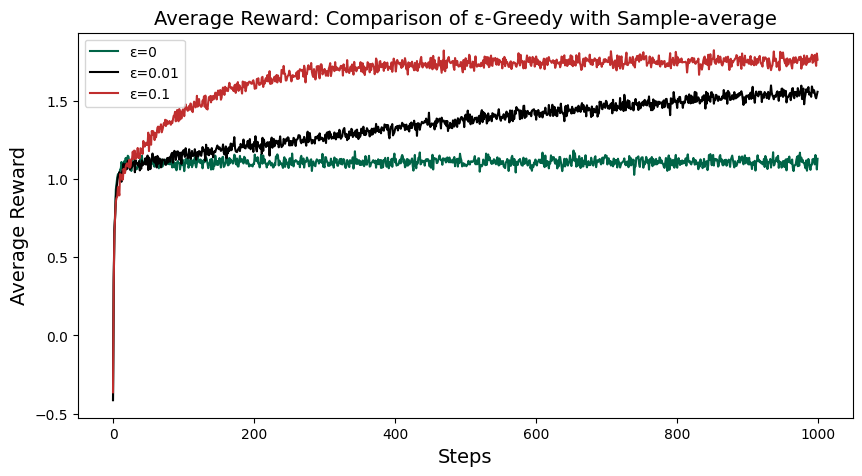

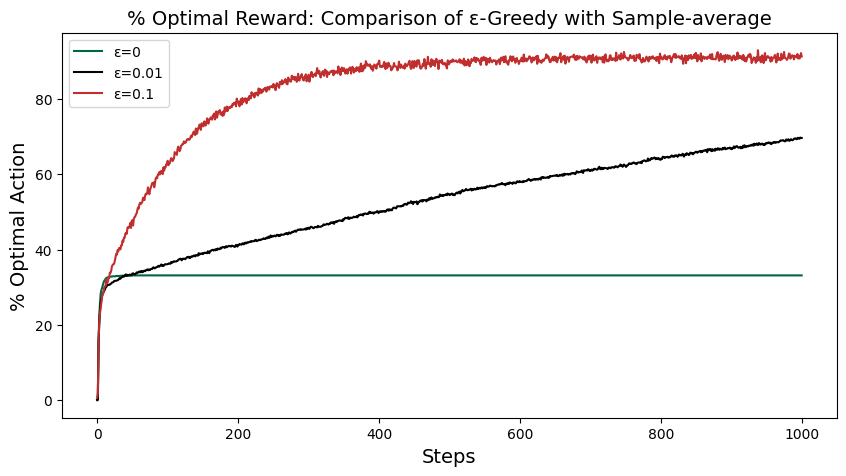

In [9]:
# Experiment 1: Sample-average with different ε values
np.random.seed(29)
stationary_bandit = MultiArmedBandit(n_arms)
epsilons = [0, 0.01, 0.1]
sample_avg_results = {}

for epsilon in epsilons:  
    reward, optimal = run_tasks(stationary_bandit, tasks, steps, epsilon=epsilon)
    sample_avg_results[epsilon] = (reward, optimal)

# Plot average reward for sample-average
plot_graph(
    {f"ε={epsilon}": reward for epsilon, (reward, _) in sample_avg_results.items()},
    ylabel="Average Reward",
    title="Average Reward: Comparison of ε-Greedy with Sample-average",
    colours=colours,
)

# Plot % optimal action for sample-average
plot_graph(
    {f"ε={epsilon}": optimal * 100 for epsilon, (_, optimal) in sample_avg_results.items()},
    ylabel="% Optimal Action",
    title="% Optimal Reward: Comparison of ε-Greedy with Sample-average",
    colours=colours,
)

### Experiment 2: Compare Exponential, Recency-Weighted Average (α=0.1) vs Sample-Average for $ \epsilon = 0.1 $ on a Stationary Machine**

#### Goal
To compare two action-value estimation methods for a stationary multi-armed bandit:
1. Sample-Average Method ($ \alpha_k = \frac{1}{N(a)} $): Averages all past rewards equally.
2. Exponential, Recency-Weighted Average ($ \alpha = 0.1 $): Weighs recent rewards more heavily.

#### Experiment Setup
- **Number of Actions (Arms):** $ N = 10 $
- **Steps per Task:** $ 1000 $
- **Number of Tasks (Runs):** $ 2000 $
- **Action Selection Method:** **ε-greedy ($ \epsilon = 0.1 $)**
- **Stationary Bandit:** True action values remain constant throughout.
- **Step-Size Methods:**
  - **Sample-Average:** $ Q_{k+1}(a) = Q_k(a) + \frac{1}{N(a)} (R_k - Q_k(a)) $
  - **Recency-Weighted Average (α = 0.1):** $ Q_{k+1}(a) = Q_k(a) + 0.1 (R_k - Q_k(a)) $

#### Methodology
1. Each bandit problem is initialized with a set of fixed true action values $ Q^*(a) $.
2. The agent estimates action values using either sample-average or constant step-size (α = 0.1).
3. Actions are selected using an ε-greedy ($ \epsilon = 0.1 $) policy.
4. Performance is measured in terms of:
   - Average Reward over Time
   - % Optimal Action Selection over Time

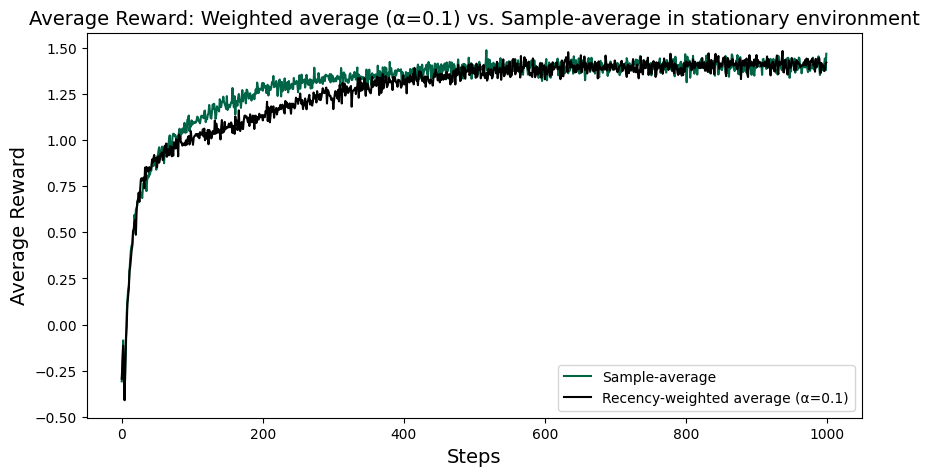

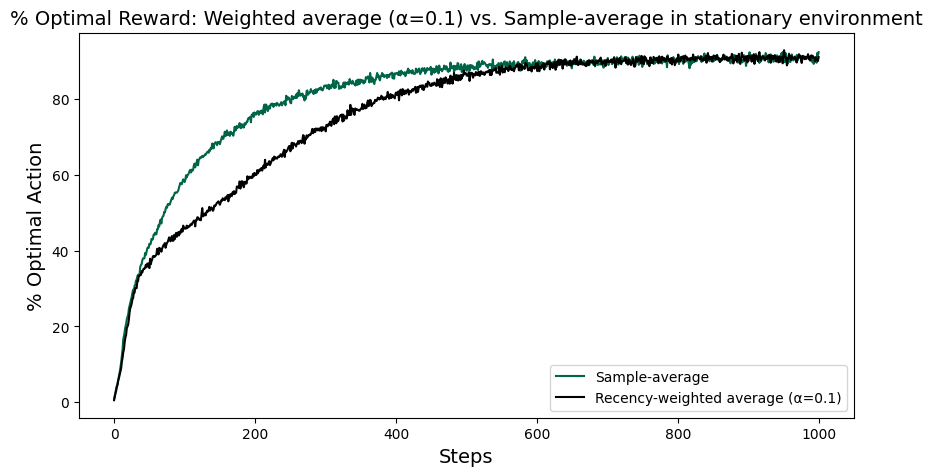

In [10]:
# Experiment 2: Compare exponential, recency-weighted average (α=0.1) vs sample-average for ε=0.1 on stationary machine
stationary_bandit = MultiArmedBandit(n_arms)
alphas = [None, 0.1]
action_value_stationary_results = {}

for alpha in alphas:
    action_value_method = "Sample-average" if alpha is None else "Recency-weighted average (α=0.1)"
    reward, optimal = run_tasks(stationary_bandit, tasks, steps, epsilon=0.1, alpha=alpha)
    action_value_stationary_results[action_value_method] = (reward, optimal)

# Plot average reward for exponential, recency-weighted average (α=0.1) vs sample-average
plot_graph(
    {action_value_method: reward for action_value_method, (reward, _) in action_value_stationary_results.items()},
    ylabel="Average Reward",
    title="Average Reward: Weighted average (α=0.1) vs. Sample-average in stationary environment",
    colours=colours,
)

# Plot % optimal action for exponential, recency-weighted average (α=0.1) vs sample-average
plot_graph(
    {action_value_method: optimal * 100 for action_value_method, (_, optimal) in action_value_stationary_results.items()},
    ylabel="% Optimal Action",
    title="% Optimal Reward: Weighted average (α=0.1) vs. Sample-average in stationary environment",
    colours=colours,
)

### Experiment 3: Compare Exponential, Recency-Weighted Average (α=0.1) vs Sample-Average for $ \epsilon = 0.1 $ on a Non-Stationary Machine

#### Goal
To compare two action-value estimation methods for a non-stationary multi-armed bandit:
1. Sample-Average Method ($ \alpha_k = \frac{1}{N(a)} $): Averages all past rewards equally.
2. Exponential, Recency-Weighted Average ($ \alpha = 0.1 $): Weighs recent rewards more heavily.

#### Experiment Setup
- **Number of Actions (Arms):** $ N = 10 $
- **Steps per Task:** $ 1000 $
- **Number of Tasks (Runs):** $ 2000 $
- **Action Selection Method:** **ε-greedy ($ \epsilon = 0.1 $)**
- **Stationary Bandit:** True action values changes over time using incremental drift.
- **Step-Size Methods:**
  - **Sample-Average:** $ Q_{k+1}(a) = Q_k(a) + \frac{1}{N(a)} (R_k - Q_k(a)) $
  - **Recency-Weighted Average (α = 0.1):** $ Q_{k+1}(a) = Q_k(a) + 0.1 (R_k - Q_k(a)) $

#### Non-Stationary Environment
To simulate a non-stationary bandit:
- At each time step, true action values drift as:
  
  $
  Q^*(a) \leftarrow Q^*(a) + N(0, \sigma)
  $

- We set:
  - $ \sigma = 0.01 $ for slow drift.
  - $ \sigma = 0.1 $ for faster changes.

#### Methodology
1. Each bandit problem starts with a random set of true action values $ Q^*(a) $.
2. Over time, true action values drift with Gaussian noise.
3. The agent estimates action values using either:
   - Sample-average method
   - Recency-weighted update (α = 0.1)
4. Actions are selected using an ε-greedy ($ \epsilon = 0.1 $) policy.
5. Performance is measured in terms of:
   - Average Reward over Time
   - % Optimal Action Selection over Time

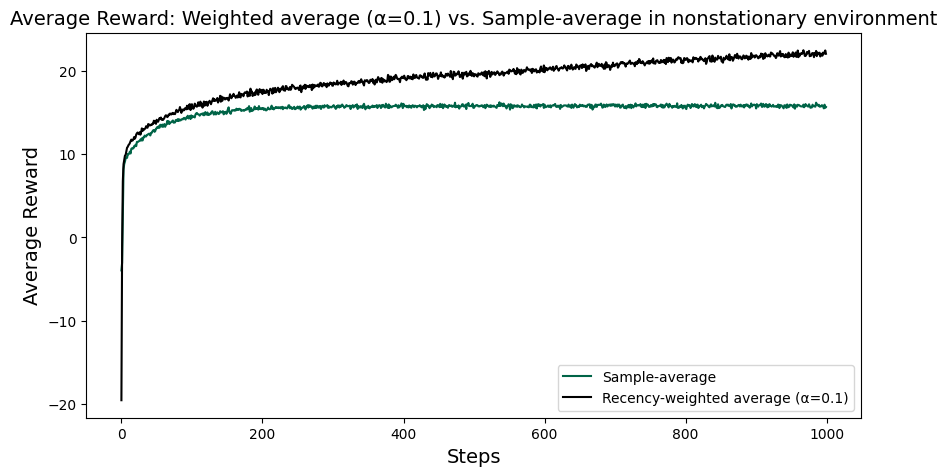

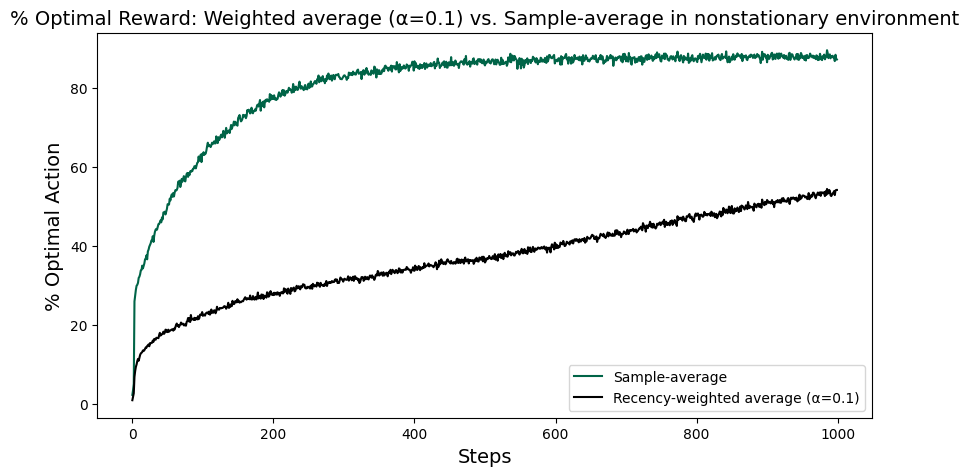

In [11]:
# Experiment 3: Compare exponential, recency-weighted average (α=0.1) vs sample-average for ε=0.1 on nonstationary machine
nonstationary_bandit = MultiArmedBandit(n_arms, stationary=False)
action_value_nonstationary_results = {}

for alpha in alphas:
    action_value_method = "Sample-average" if alpha is None else "Recency-weighted average (α=0.1)"
    reward, optimal = run_tasks(nonstationary_bandit, tasks, steps, epsilon=0.1, alpha=alpha)
    action_value_nonstationary_results[action_value_method] = (reward, optimal)

# Plot average reward for exponential, recency-weighted average (α=0.1) vs sample-average
plot_graph(
    {action_value_method: reward for action_value_method, (reward, _) in action_value_nonstationary_results.items()},
    ylabel="Average Reward",
    title="Average Reward: Weighted average (α=0.1) vs. Sample-average in nonstationary environment",
    colours=colours,
)

# Plot % optimal action for exponential, recency-weighted average (α=0.1) vs sample-average
plot_graph(
    {action_value_method: optimal * 100 for action_value_method, (_, optimal) in action_value_nonstationary_results.items()},
    ylabel="% Optimal Action",
    title="% Optimal Reward: Weighted average (α=0.1) vs. Sample-average in nonstationary environment",
    colours=colours,
)

### Experiment 4: Compare Optimistic (Q=5) vs Realistic (Q=0) Initial Values

#### Goal
To compare the effects of optimistic initial values and realistic initial values in a multi-armed bandit problem.

#### Experiment Setup
- **Number of Actions (Arms):** $ N = 10 $
- **Steps per Task:** $ 1000 $
- **Number of Tasks (Runs):** $ 2000 $
- **Action Selection Method:**
  - **Optimistic Initial Values:** $ Q_1 = 5, \epsilon = 0 $ (fully greedy)
  - **Realistic Initial Values:** $ Q_1 = 0, \epsilon = 0.1 $ (ε-greedy)
- **Stationary Bandit:** True action values remain fixed over time.

#### Methodology
1. Each bandit problem is initialized with a set of fixed true action values $ Q^*(a) $.
2. The agent estimates action values using sample-average.
   - Optimistic Initial Values ($ Q_1 = 5, \epsilon = 0 $)
     - The initial estimates is taken as 5 for all actions.
     - Actions are selected using a greedy strategy ($ ε = 0 $) (always picks the action with the highest estimated value). 
   - Realistic Initial Values ($ Q_1 = 0, \epsilon = 0.1 $)
     - The initial estimates is taken as 0 for all actions.
     - Actions are selected using an ε-greedy strategy ($ \epsilon = 0.1 $), meaning 10% of actions are random.
3. Performance is measured in terms of:
   - Average Reward over Time
   - % Optimal Action Selection over Time

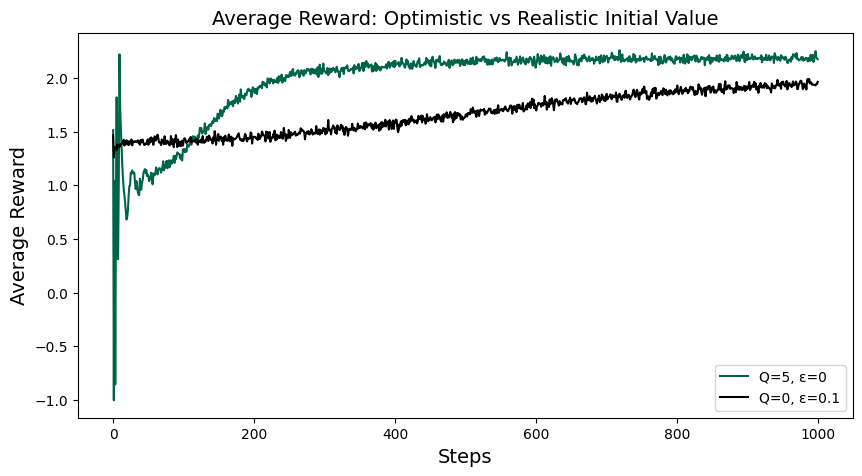

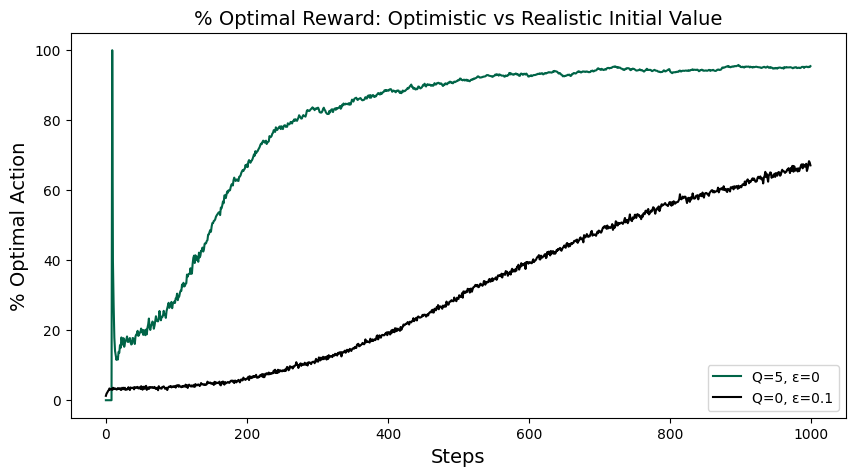

In [ ]:
# Experiment 4: Compare optimistic (Q=5) vs realistic initial values (Q=0)
stationary_bandit = MultiArmedBandit(n_arms)
initial_value_results = {}
params = [{"initial": 5, "epsilon": 0}, {"initial": 0, "epsilon": 0.1}]

for param in params:
    label = f"Q={param['initial']}, ε={param['epsilon']}"
    reward, optimal = run_tasks(stationary_bandit, tasks, steps, epsilon=param["epsilon"], alpha=0.1, initial_value=param["initial"])
    initial_value_results[label] = (reward, optimal)

# Plot average reward for optimistic vs realistic initial values
plot_graph(
    {label: reward for label, (reward, _) in initial_value_results.items()},
    ylabel="Average Reward",
    title="Average Reward: Optimistic vs Realistic Initial Value",
    colours=colours,
)

# Plot % optimal action for optimistic vs realistic initial values
plot_graph(
    {label: optimal * 100 for label, (_, optimal) in initial_value_results.items()},
    ylabel="% Optimal Action",
    title="% Optimal Reward: Optimistic vs Realistic Initial Value",
    colours=colours,
)

#### Experiment 5: UCB (c=2) vs. ε-Greedy (ε=0.1) Action Selection

#### Goal
To compare the performance of Upper Confidence Bound (UCB) action selection against the ε-Greedy method.

#### Experiment Setup
- **Number of Actions (Arms):** $ N = 10 $
- **Steps per Task:** $ 1000 $
- **Number of Tasks (Runs):** $ 2000 $
- **Action Selection Methods:**
  - **UCB:** $ c = 2 $
  - **ε-Greedy:** $ \epsilon = 0.1 $
- **Stationary Bandit:** True action values remain fixed over time.

#### Methodology
1. Each bandit problem is initialized with a set of fixed true action values $ Q^*(a) $.
2. The agent estimates action values using sample-average.
3. Actions are selected using either:
   - ε-greedy ($ \epsilon = 0.1 $) policy.
   - UCB (c=2) method.
4. Performance is measured in terms of:
   - Average Reward over Time
   - % Optimal Action Selection over Time


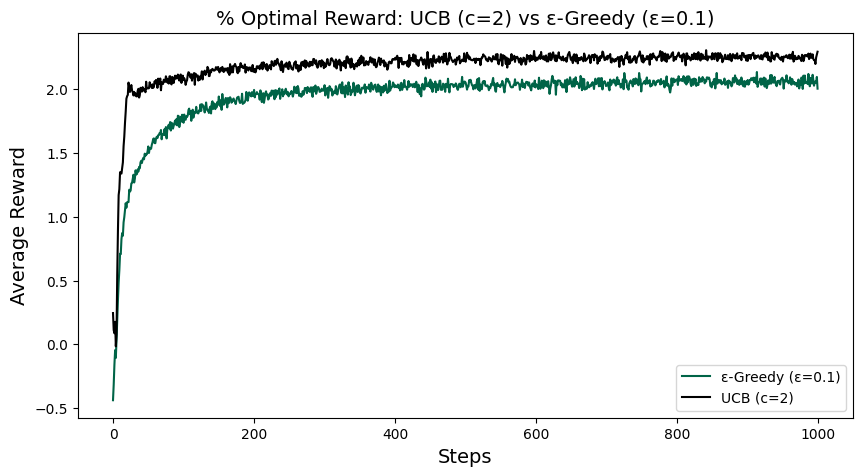

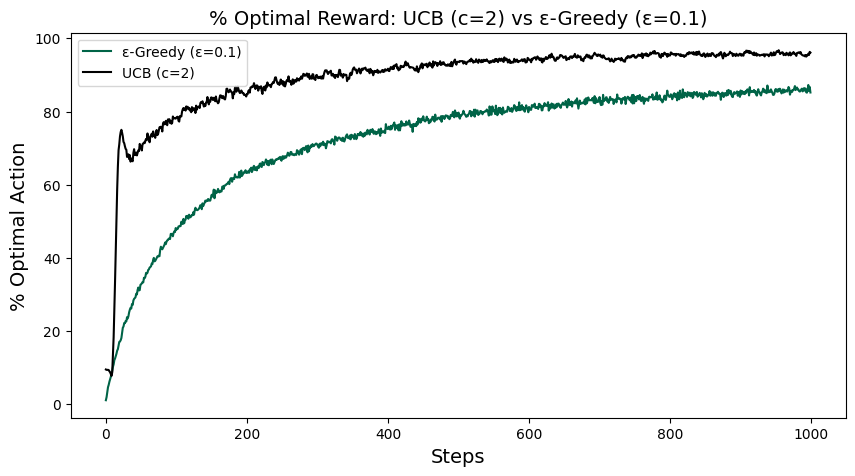

In [ ]:
# Experiment 5: UCB (c=2) vs ε-Greedy (ε=0.1) Action Selection
stationary_bandit = MultiArmedBandit(n_arms)
action_selector_results = {}
action_selectors = {
        "ε-Greedy (ε=0.1)": {"action_selector": "epsilon-greedy", "epsilon": 0.1},
        "UCB (c=2)": {"action_selector": "ucb", "c": 2}
    }
for label, params in action_selectors.items():
    reward, optimal = run_tasks(stationary_bandit, tasks, steps, **params)
    action_selector_results[label] = (reward, optimal)

# Plot average reward for UCB (c=2) vs ε-Greedy (ε=0.1) Action Selection
plot_graph(
    {label: reward for label, (reward, _) in action_selector_results.items()},
    ylabel="Average Reward",
    title="Average Reward: UCB (c=2) vs ε-Greedy (ε=0.1)",
    colours=colours,
)

# Plot % optimal action for UCB (c=2) vs ε-Greedy (ε=0.1) Action Selection
plot_graph(
    {label: optimal * 100 for label, (_, optimal) in action_selector_results.items()},
    ylabel="% Optimal Action",
    title="% Optimal Reward: UCB (c=2) vs ε-Greedy (ε=0.1)",
    colours=colours,
)

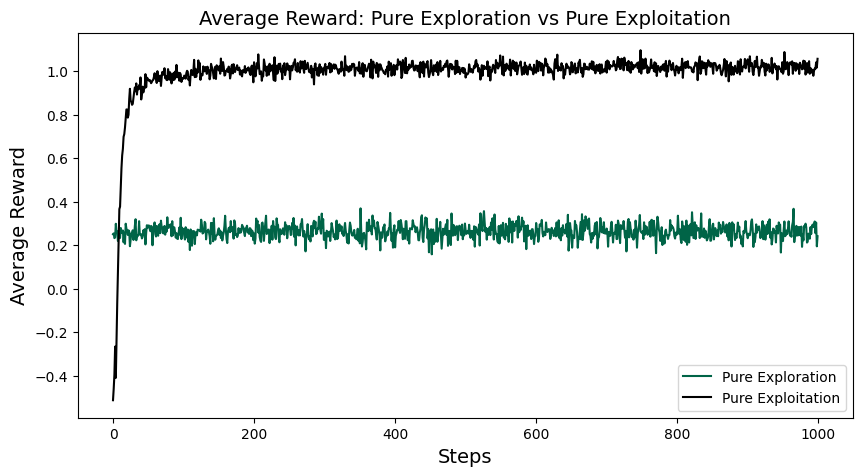

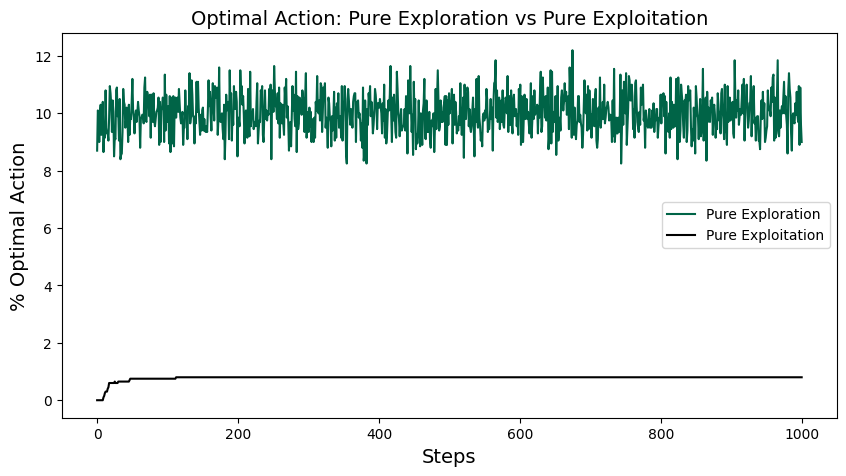

In [15]:
# Pure Exploration: ε=1.0 (always random)
pure_exploration_reward, pure_exploration_optimal = run_tasks(
    stationary_bandit, tasks, steps, action_selector="epsilon-greedy", epsilon=1.0
)
 
# Pure Exploitation: ε=0.0 (always pick the best estimated action)
pure_exploitation_reward, pure_exploitation_optimal = run_tasks(
    stationary_bandit, tasks, steps, action_selector="epsilon-greedy", epsilon=0.0
)
 
# Plot average reward comparison
plot_graph(
    {
        "Pure Exploration": pure_exploration_reward,
        "Pure Exploitation": pure_exploitation_reward
    },
    ylabel="Average Reward",
    title="Average Reward: Pure Exploration vs Pure Exploitation",
    colours=colours
)
 
# Plot % optimal action comparison
plot_graph(
    {
        "Pure Exploration": pure_exploration_optimal * 100,
        "Pure Exploitation": pure_exploitation_optimal * 100
    },
    ylabel="% Optimal Action",
    title="Optimal Action: Pure Exploration vs Pure Exploitation",
    colours=colours
)